**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 9**
Regresión Logística

---

*   NOMBRE: Ricardo Martin Galvan Paez
*   MATRÍCULA: A01253169

En esta actividad trabajarás con el archivo `breast_cancer.csv`, basado en un conjunto de datos sobre características de tumores mamarios, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar si un tumor es maligno (M) o benigno (B) a partir de medidas extraídas de imágenes de biopsias. Las variables incluidas describen propiedades morfológicas y de textura del tumor y se presentan en tres tipos de medida para cada característica:

* `_mean`: valor promedio de la característica en el tumor
* `_se`: error estándar de la característica (variabilidad de la medición)
* `_worst`: peor valor observado de la característica en el tumor

Los indicadores incluidos son:
* `radius_mean` / `radius_se` / `radius_worst`:	Radio del tumor
* `texture_mean` / `texture_se` / `texture_worst`:	Textura del tumor (desviación estándar de intensidad)
* `perimeter_mean` / `perimeter_se` / `perimeter_worst`:	Perímetro del tumor
* `area_mean` / `area_se` / `area_worst`:	Área del tumor
* `smoothness_mean` / `smoothness_se` / `smoothness_worst`:	Suavidad (irregularidad del borde)
* `compactness_mean` / `compactness_se` / `compactness_worst`:	Compacidad (perimeter^2 / area - 1)
* `concavity_mean` / `concavity_se` / `concavity_worst`:	Concavidad de los contornos
* `concave points_mean` / `concave points_se` / `concave points_worst`:	Número de puntos cóncavos en el contorno
* `symmetry_mean` / `symmetry_se` / `symmetry_worst`:	Simetría del tumor
* `fractal_dimension_mean` / `fractal_dimension_se` / `fractal_dimension_worst`:	Dimensión fractal del contorno (complejidad)
* `diagnosis`: Indica si el tumor es benigno (B) o maligno (M). Es la variable de salida o *target*

In [ ]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
DIR = "/content/drive/MyDrive/Posgrado/1er trimestre/TC5053.10_Ciencia y analítica de datos/Colab/Actividad 9 | Regresión logística"
os.chdir(DIR)

1. Descarga el archivo: `breast_cancer.csv` y guarda, en un dataframe (`cancer_df`), todos sus registros.
* Haz que la columna `id` sea el nuevo índice.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Verifica si alguna columna contiene valores faltantes.
* Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.
* Obtén las estadísticas descriptivas, separando las variables numéricas (con asimetría y curtosis) y las categóricas.

In [ ]:
cancer_df = pd.read_csv('breast_cancer.csv')
cancer_df.set_index('id', inplace=True)
cancer_df.info()
print('='*50)
num_cols = cancer_df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = cancer_df.select_dtypes(include=['object']).columns

print(f'Columnas numéricas: {len(num_cols)}')
print(f'Columnas categóricas: {len(cat_cols)}')
print('='*50)

#Valores faltantes
print(f'Valores faltantes: \n{cancer_df.isnull().sum()}')
print('='*50)

#Valores duplicados
print(f'Valores duplicados: {cancer_df.duplicated().sum()}')
print('='*50)

#Estadisticas descriptivas
print('Estadisticas descriptivas numericas:')
describe_df = cancer_df[num_cols].describe().T
describe_df['asimetria'] = cancer_df[num_cols].skew()
describe_df['curtosis'] = cancer_df[num_cols].kurtosis()
display(describe_df)
print('='*50)
print('Estadisticas descriptivas categoricas:')
display(cancer_df[cat_cols].describe())

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                 

,count,mean,std,min,25%,50%,75%,max,asimetria,curtosis
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000,0.942380,0.845522
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000,0.650450,0.758319
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000,0.990650,0.972214
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000,1.645732,3.652303
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340,0.456324,0.855975
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540,1.190123,1.650130
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680,1.401180,1.998638
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120,1.171180,1.066556
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400,0.725609,1.287933
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744,1.304489,3.005892


Estadisticas descriptivas categoricas:


,diagnosis
count,569
unique,2
top,B
freq,357


2. Explora relaciones bivariadas en el conjunto de datos mediante gráficos:
* Calcula y visualiza la distribución porcentual de la variable `diagnosis` usando un gráfico de barras, mostrando el porcentaje encima de cada barra. ¿Por qué la distribución de la salida es relevante en un problema de clasificación?
* Genera un pairplot de las variables físicas del conjunto _mean (`radius_mean`, `perimeter_mean`, `area_mean`, `texture_mean`) coloreando por la variable `diagnosis`. ¿Qué relaciones observas entre las variables físicas? ¿Qué diferencias hay entre los tumores benignos y malignos?
* Crea histogramas apilados de las variables morfológicas (`smoothness_mean`, `compactness_mean`, `concavity_mean`, `concave points_mean`, `symmetry_mean`, `fractal_dimension_mean`) coloreando por `diagnosis` para explorar la distribución de cada variable según el tipo de tumor. ¿Alguna variable parece ser un buen discriminador entre las clases?




---
La distribución de la variable objetivo es crítica ya que revela si las clases estan balanceadas o desbalanceadas. Si una clase domina considerablemente, el modelo puede alcanzar un accuarcy alto prediciondo simepre la clase amyoritaria, sin aprender ningun patron real


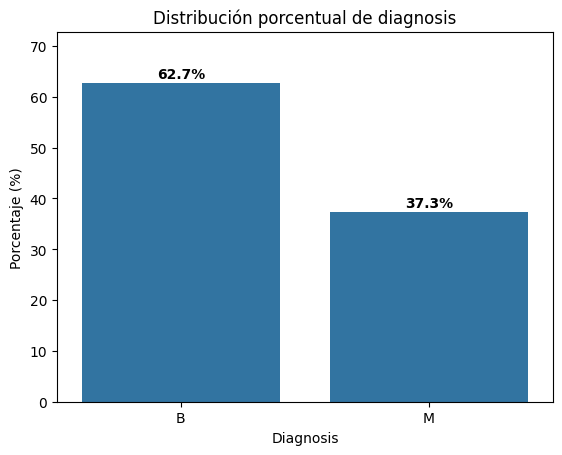

In [ ]:
#Distribucion de variable target %
dist = cancer_df['diagnosis'].value_counts(normalize=True) * 100

ax = sns.barplot(x=dist.index, y=dist.values)
# Agregar porcentaje encima de cada barra
for i, v in enumerate(dist.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.title('Distribución porcentual de diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Porcentaje (%)')
plt.ylim(0, max(dist.values) + 10)
plt.show()


Se observa una relación lineal casi perfecta entre radius_mean, perimeter_mean y area_mean, lo cual es esperado dado que estas tres variables son matemáticamente dependientes entre sí, por lo que probablemente no sea necesario conservar las tres en el modelo.

La variable objetivo, se observa que los diagnósticos malignos (M) tienden a concentrarse en valores más altos, es decir, tumores físicamente más grandes tienen mayor probabilidad de ser malignos.

Por otro lado, texture_mean también muestra separación entre clases, aunque con mayor traslape entre ambas distribuciones comparado con las variables de tamaño. No presenta relación lineal con las variables de tamaño, lo que sugiere que aporta información complementaria e independiente al modelo.

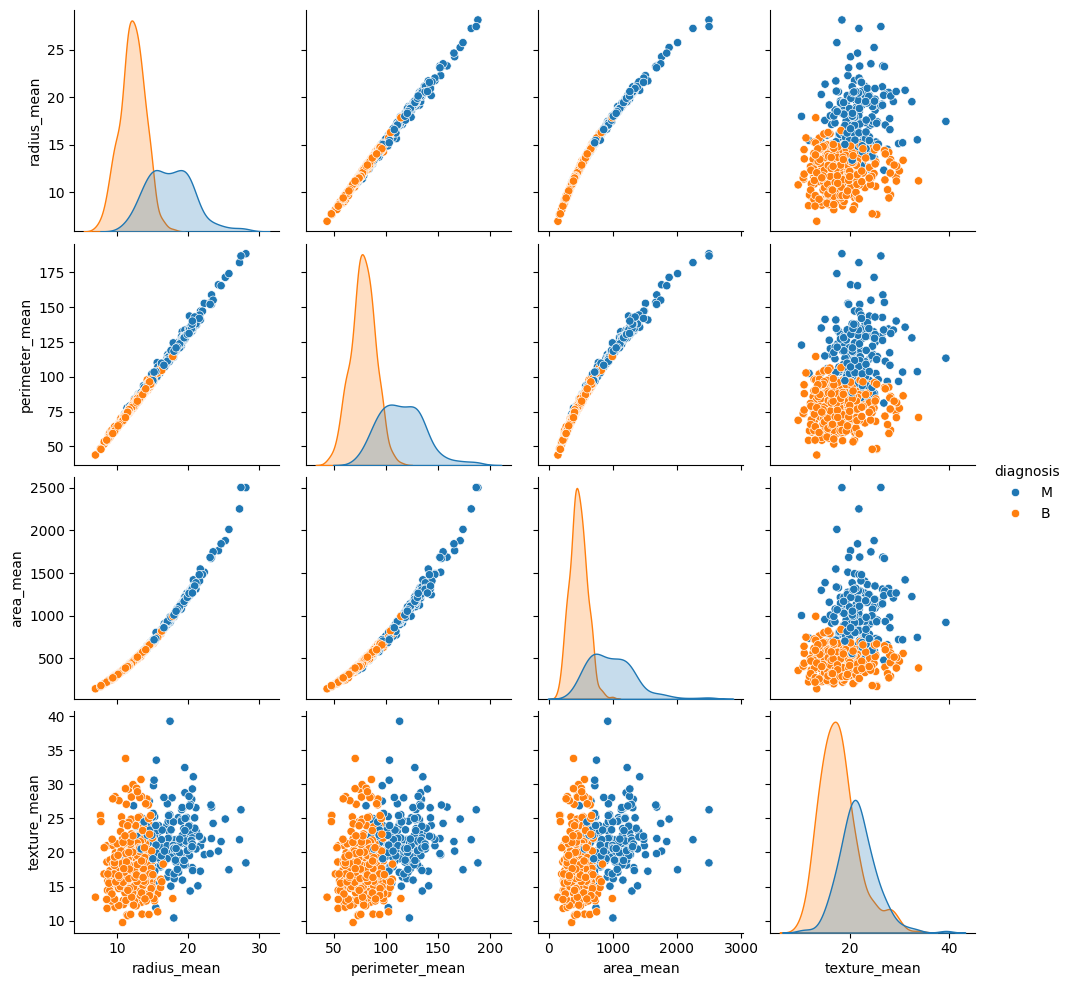

In [ ]:
#Pairplot de variables fisicas _mean
sns.pairplot(cancer_df[['radius_mean', 'perimeter_mean', 'area_mean', 'texture_mean', 'diagnosis']], hue='diagnosis')
plt.show()

Se observa que concavity_mean y concave points_mean son las variables con mayor poder discriminante entre clases. Aunque ambas distribuciones se traslapan en valores bajos.  en valores medios-altos la distribución se vuelve predominantemente maligna (M), con muy pocos casos benignos presentes.

Un valor alto es un fuerte indicador de malignidad. Y de igual froma concave points_mean no tiene ni un valor benigno en valores altos, y concavity_mean cuenta con muy pocos valores como outliers

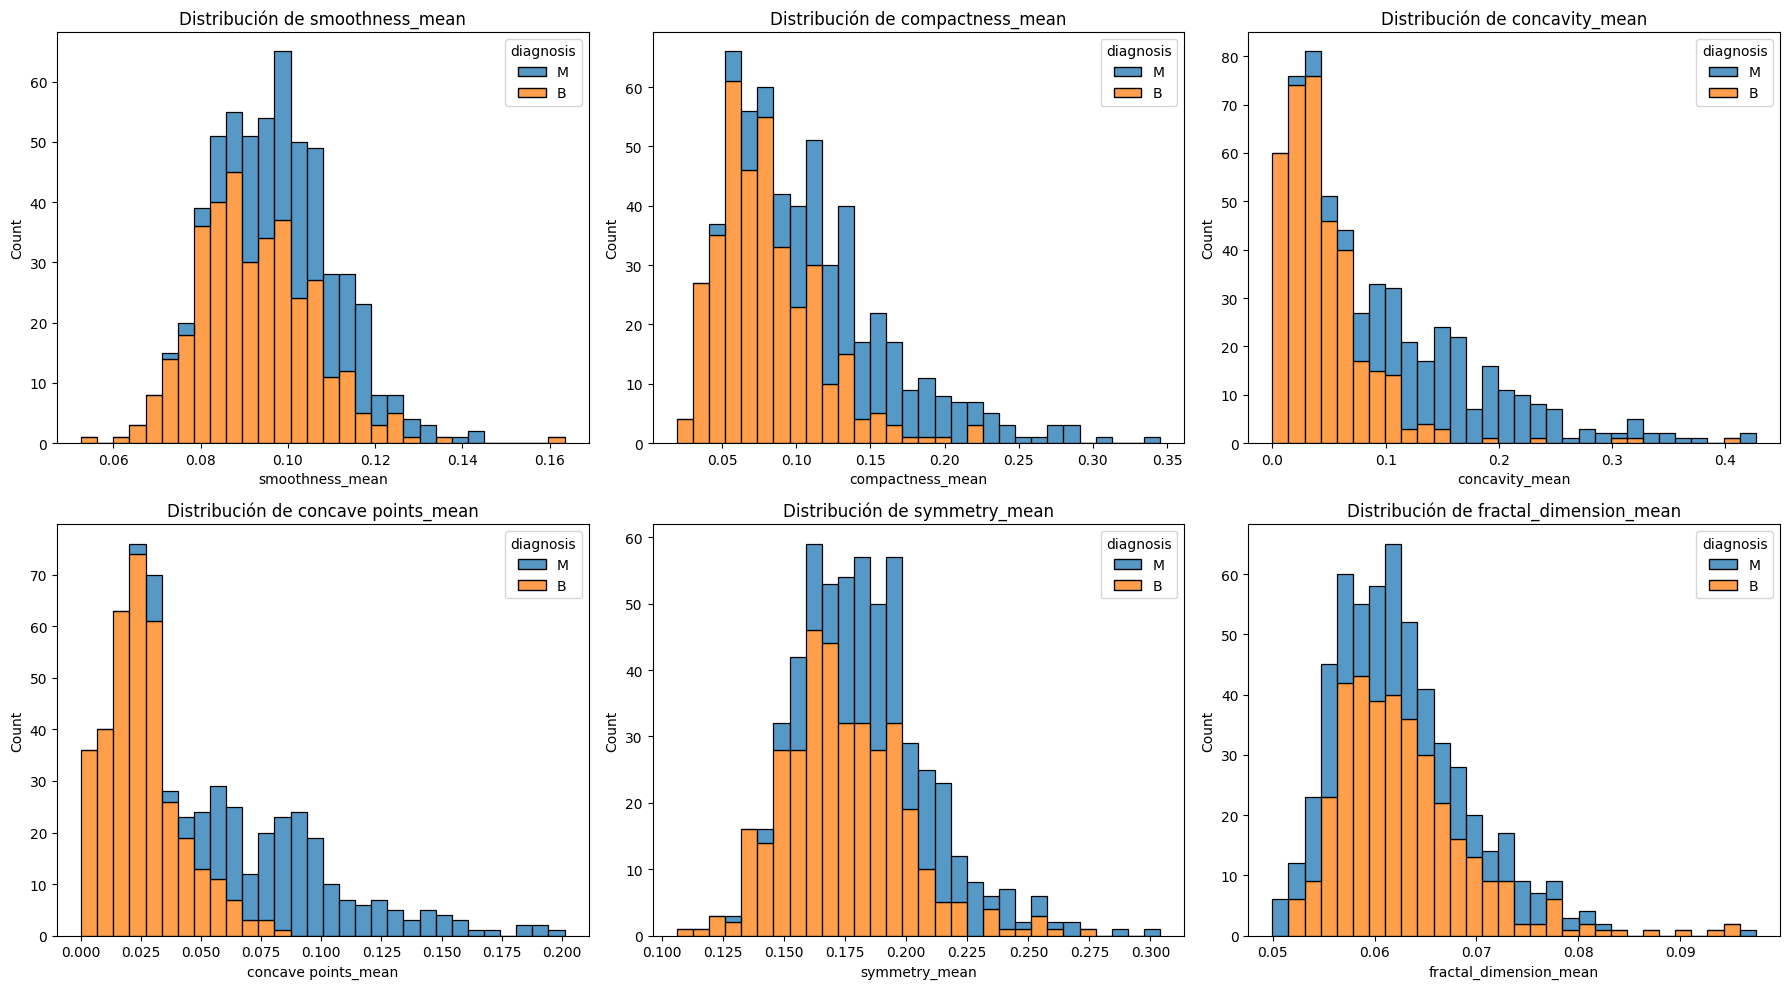

In [ ]:
morfologicas = ['smoothness_mean', 'compactness_mean', 'concavity_mean',
                 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(morfologicas):
    sns.histplot(data=cancer_df, x=col, hue='diagnosis', multiple='stack',
                 bins=30, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

3. Antes de realizar el análisis de correlación, crea una copia del dataframe (`cancer_copy`).
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos. La alta correlación entre las variables del conjunto _mean y _worst es inevitable, ya que las columnas _worst representan esencialmente los valores máximos de las mismas características medidas en _mean. Elimina las columnas _worst para simplificar el análisis.
* Imprime nuevamente los pares con correlación superior a 0.9. Como habías observado previamente, existen relaciones lineales entre `radius`, `perimeter` y `area`, por lo que era esperable encontrar altas correlaciones. De estas tres medidas, ¿cuál mantendrías y por qué? Elimina todas las variables de los otros dos conjuntos.
* Dibuja un mapa de calor con la matriz de correlación para identificar si prevalece alguna correlación relevante. Si eliminas alguna otra variable, justifica tu elección.

In [ ]:
cancer_copy = cancer_df.copy()

In [ ]:
#Correlacion mayor a 0.9
corr_matrix = cancer_copy.corr(numeric_only=True)
#Encontrar mayores a 0.9
corr_altas = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            corr_altas.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
corr_altas_df = pd.DataFrame(corr_altas, columns=['Variable 1', 'Variable 2', 'Correlacion']).sort_values(by='Correlacion', ascending=False)
display(corr_altas_df)

,Variable 1,Variable 2,Correlacion
0,radius_mean,perimeter_mean,0.997855
18,radius_worst,perimeter_worst,0.993708
1,radius_mean,area_mean,0.987357
6,perimeter_mean,area_mean,0.986507
19,radius_worst,area_worst,0.984015
20,perimeter_worst,area_worst,0.977578
15,radius_se,perimeter_se,0.972794
8,perimeter_mean,perimeter_worst,0.970387
2,radius_mean,radius_worst,0.969539
7,perimeter_mean,radius_worst,0.969476


In [ ]:
worst_cols = [col for col in cancer_copy.columns if '_worst' in col]
cancer_copy.drop(columns=worst_cols, inplace=True)

#Correlacion mayor a 0.9
corr_matrix = cancer_copy.corr(numeric_only=True)
#Encontrar mayores a 0.9
corr_altas = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            corr_altas.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
corr_altas_df = pd.DataFrame(corr_altas, columns=['Variable 1', 'Variable 2', 'Correlacion']).sort_values(by='Correlacion', ascending=False)
display(corr_altas_df)

,Variable 1,Variable 2,Correlacion
0,radius_mean,perimeter_mean,0.997855
1,radius_mean,area_mean,0.987357
2,perimeter_mean,area_mean,0.986507
4,radius_se,perimeter_se,0.972794
5,radius_se,area_se,0.951830
6,perimeter_se,area_se,0.937655
3,concavity_mean,concave points_mean,0.921391


Para decidir cuál variable conservar dentro de cada grupo de variables
altamente correlacionadas entre sí, evaluamos la correlación individual
de cada una con el target y conservamos la más discriminatoria

- **Grupo _mean**: conservamos `perimeter_mean` por presentar mayor
  correlación con el target frente a sus pares del grupo.
- **Grupo se**: conservamos `radius_se` por presentar mayor
  correlación con el target frente a sus pares del grupo.
-  **Concavity vs. concave points**: comparando `concavity_mean` y
  `concave points_mean`, conservamos `concave points_mean`, que mostró
  una diferencia de correlación más notoria al comparar `concavity_mean`.


In [ ]:
#Analisis de corr vs target individual
diagnosis_num = cancer_df['diagnosis'].map({'M':1, 'B':0})
print(cancer_df[['radius_mean', 'perimeter_mean', 'area_mean']].corrwith(diagnosis_num))
print(cancer_df[['radius_se', 'perimeter_se', 'area_se']].corrwith(diagnosis_num))
print(cancer_df[['concavity_mean', 'concave points_mean']].corrwith(diagnosis_num))

radius_mean       0.730029
perimeter_mean    0.742636
area_mean         0.708984
dtype: float64
radius_se       0.567134
perimeter_se    0.556141
area_se         0.548236
dtype: float64
concavity_mean         0.696360
concave points_mean    0.776614
dtype: float64


In [ ]:
cancer_copy.drop(columns=['radius_mean', 'area_mean', 'concavity_mean', 'perimeter_se', 'area_se'], inplace=True)

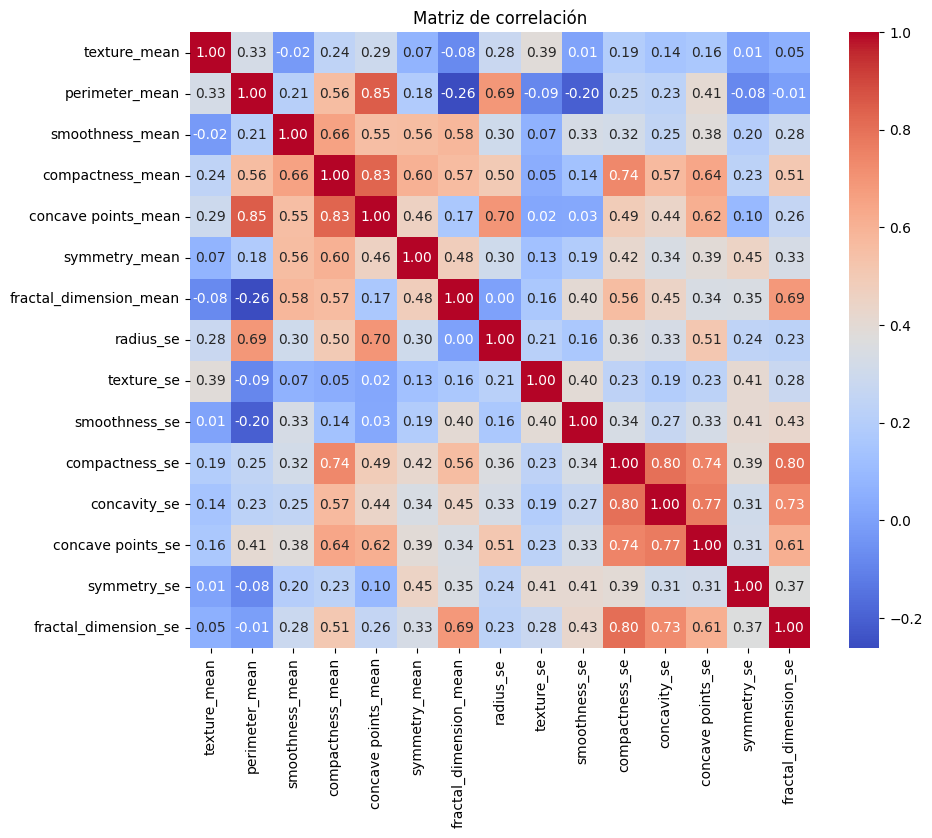

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(cancer_copy.corr(numeric_only=True), annot=True, cmap='coolwarm',fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

4. Separa las variables predictoras `X` de la variable de salida `y`, usando el dataframe original `cancer_df` (la eliminación de variables correlacionadas se integrará en el pipeline).
* Codifica `diagnosis` como 0 (Benigno) y 1 (Maligno).
* Divide el conjunto de datos en entrenamiento y prueba (80:20), usando `random_state=1` para garantizar reproducibilidad.
* Para evaluar los modelos que se construirán, define una función llamada `evaluate_model` que reciba los valores reales y las predicciones e imprima las métricas de recall, precisión y exactitud (accuracy).

In [ ]:
#Separacion de variables
x = cancer_df.drop(columns=['diagnosis'])
y = cancer_df['diagnosis'].map({'M':1, 'B':0})

#Separar el conjunto de datos en train y test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

#Evaluacion de modelo
def evaluate_model(actual, predicted):

    print(f'Recall: {recall_score(actual, predicted)}')
    print(f'Precision: {precision_score(actual, predicted)}')
    print(f'Accuracy: {accuracy_score(actual, predicted)}')

5. Prepara un transformador denominado `preprocessing`, usando ColumnTransformer, para borrar las columnas altamente correlacionadas (identificadas en el ejercicio 3) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.
* Crea un pipeline que integre el transformador y regresión logística para  entrenar un modelo.
* Evalúa el desempeño del modelo en el conjunto de prueba empleando la función `evaluate_model`.
* Integra los resultados en un dataframe que contenga el nombre del modelo (*Correlation_Clean*) y una columna para cada métrica calculada.

In [ ]:
#_worst + columnas a eliminar
worst_cols += ['radius_mean', 'area_mean', 'concavity_mean', 'perimeter_se', 'area_se']
#Transformador previo a trabajr sobre los datos
preprocessing = ColumnTransformer([
    ('drop_columns', 'drop', worst_cols)
    ], remainder='passthrough')

#Pipeline para el modelo de regresion logistica
logr_model = make_pipeline(preprocessing, LogisticRegression(max_iter=10000))
logr_model.fit(x_train, y_train)
y_pred = logr_model.predict(x_test)
evaluate_model(y_test, y_pred)


#Dataframe
resultados = pd.DataFrame(columns=['Modelo', 'Recall', 'Precision', 'Accuracy'])
resultados.loc[0] = ['Correlation_Clean', recall_score(y_test, y_pred), precision_score(y_test, y_pred), accuracy_score(y_test, y_pred)]
display(resultados)

Recall: 0.7619047619047619
Precision: 0.8888888888888888
Accuracy: 0.8771929824561403


,Modelo,Recall,Precision,Accuracy
0,Correlation_Clean,0.761905,0.888889,0.877193


6. Una alternativa para reducir la multicolinealidad es el análisis de componentes principales. Construye un pipeline que incluya escalado estándar, PCA y regresión logística, manteniendo el número mínimo de componentes principales que expliquen al menos el 90% de la varianza.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Standard_PCA*.
* ¿Cuántos componentes principales se emplearon?

In [ ]:
logr_model_pca = make_pipeline(preprocessing, StandardScaler(), PCA(n_components=0.90), LogisticRegression(max_iter=10000))
logr_model_pca.fit(x_train, y_train)
y_pred = logr_model_pca.predict(x_test)
evaluate_model(y_test, y_pred)

resultados.loc[1] = ['Standard_PCA', recall_score(y_test, y_pred), precision_score(y_test, y_pred), accuracy_score(y_test, y_pred)]
display(resultados)

Recall: 0.9047619047619048
Precision: 0.9743589743589743
Accuracy: 0.956140350877193


,Modelo,Recall,Precision,Accuracy
0,Correlation_Clean,0.761905,0.888889,0.877193
1,Standard_PCA,0.904762,0.974359,0.956140


7. Como intento de mejorar las métricas del modelo, y dado que todas las variables presentan sesgo, aplica una normalización utilizando Yeo-Johnson. Para ello:
* Crea un pipeline que integre el transformador `preprocessing`, una transformación Yeo-Johnson y regresión logística.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Correlation_Yeo*.

In [ ]:
logr_model_yeo = make_pipeline(preprocessing, PowerTransformer(method="yeo-johnson"), LogisticRegression(max_iter=10000))
logr_model_yeo.fit(x_train, y_train)
y_pred_yeo = logr_model_yeo.predict(x_test)
evaluate_model(y_test, y_pred)

resultados.loc[2] = ['Correlation_Yeo', recall_score(y_test, y_pred_yeo), precision_score(y_test, y_pred_yeo), accuracy_score(y_test, y_pred_yeo)]
display(resultados)

Recall: 0.9047619047619048
Precision: 0.9743589743589743
Accuracy: 0.956140350877193


,Modelo,Recall,Precision,Accuracy
0,Correlation_Clean,0.761905,0.888889,0.877193
1,Standard_PCA,0.904762,0.974359,0.956140
2,Correlation_Yeo,0.952381,1.000000,0.982456


8. Del modelo anterior, obtén los nombres de los predictores empleados. ¿Cuántos son?
* Revisa los coeficientes del modelo de regresión logística y analiza su magnitud para identificar las variables 10 más influyentes.
* Grafícalas en un barplot horizontal, mostrando el valor del coeficiente y respetando su signo.

In [ ]:
# 1. Nombres de los predictores empleados
columnames = logr_model_yeo.named_steps['columntransformer'].get_feature_names_out()
yeo_names = logr_model_yeo.named_steps['powertransformer'].get_feature_names_out(columnames)
coefs = logr_model_yeo.named_steps['logisticregression'].coef_[0]
print(f'Número de predictores:', len(yeo_names))
print(yeo_names)

Número de predictores: 15
['remainder__texture_mean' 'remainder__perimeter_mean'
 'remainder__smoothness_mean' 'remainder__compactness_mean'
 'remainder__concave points_mean' 'remainder__symmetry_mean'
 'remainder__fractal_dimension_mean' 'remainder__radius_se'
 'remainder__texture_se' 'remainder__smoothness_se'
 'remainder__compactness_se' 'remainder__concavity_se'
 'remainder__concave points_se' 'remainder__symmetry_se'
 'remainder__fractal_dimension_se']


In [ ]:
coef_df = pd.DataFrame({'Nombre': yeo_names, 'Coeficientes': coefs})
coef_df['Coef_abs'] = coef_df['Coeficientes'].abs()
coef_df.sort_values('Coef_abs', ascending=False, inplace=True)
coef_df.head(10)

,Nombre,Coeficientes,Coef_abs
4,remainder__concave points_mean,2.437213,2.437213
0,remainder__texture_mean,1.901142,1.901142
1,remainder__perimeter_mean,1.444827,1.444827
7,remainder__radius_se,1.325590,1.325590
11,remainder__concavity_se,0.999924,0.999924
5,remainder__symmetry_mean,0.783934,0.783934
13,remainder__symmetry_se,-0.723084,0.723084
10,remainder__compactness_se,-0.706822,0.706822
3,remainder__compactness_mean,0.582670,0.582670
12,remainder__concave points_se,-0.564883,0.564883


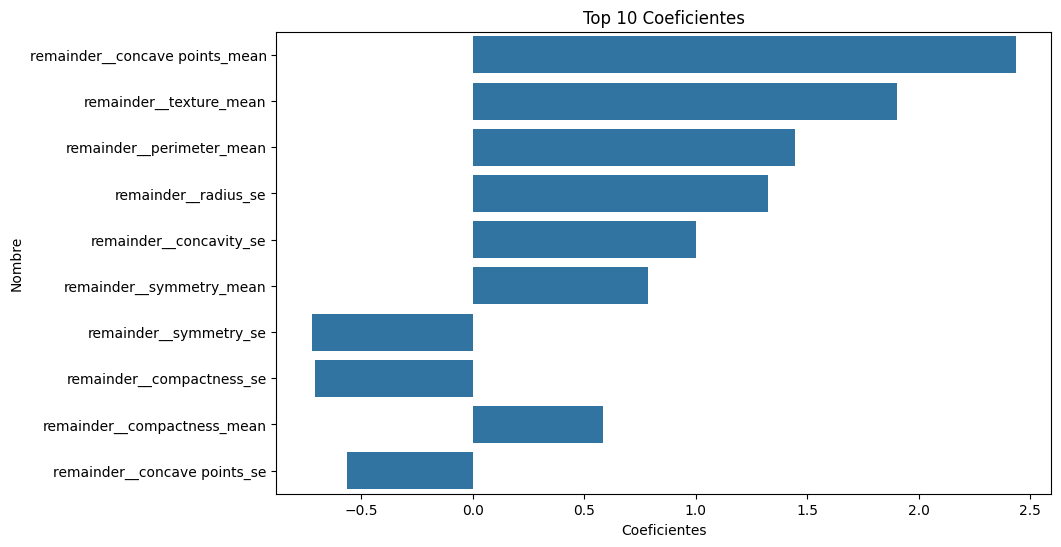

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficientes', y='Nombre', data=coef_df.head(10))
plt.title('Top 10 Coeficientes')
plt.show()

9. Imprime el dataframe de resultados.
* Dibuja la matriz de confusión del mejor modelo. ¿Qué significa cada valor en ella?
* Dibuja la curva ROC del mismo modelo y describe lo que indica sobre su capacidad para distinguir entre clases.



---
Con esta matriz de confusión (VN=72, FP=0, FN=2, VP=40), el aspecto más crítico a vigilar son los Falsos Negativos, ya que representan pacientes con cáncer real que el modelo clasificó erróneamente como benignos — un error con consecuencias clínicas graves al retrasar el diagnóstico y tratamiento. Por esta razón, se prioriza el Recall como métrica principal de evaluación.

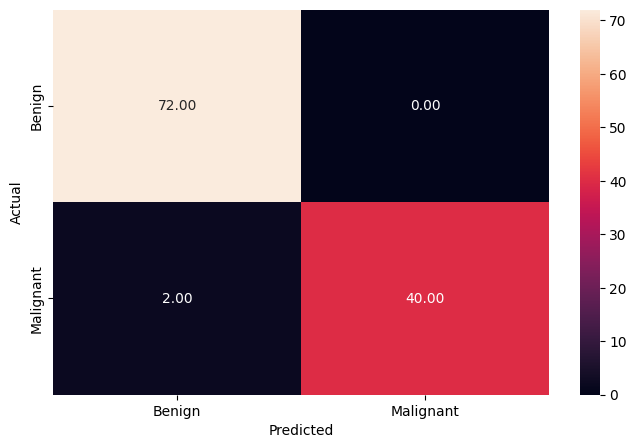

In [ ]:
cm = confusion_matrix(y_test, y_pred_yeo)
plt.figure(figsize = (8, 5))
sns.heatmap(cm, annot = True, fmt = '.2f', xticklabels = ['Benign', 'Malignant'], yticklabels = ['Benign', 'Malignant'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Muestra un AUC de 0.99, indicando una capacidad casi perfecta para distinguir entre diagnósticos benignos y malignos. La curva se aproxima fuertemente a la esquina superior izquierda. Esto confirma que, independientemente del umbral de decisión elegido, el modelo logra separar ambas clases con muy alta confiabilidad, muy por encima del clasificador aleatorio representado por la línea diagonal

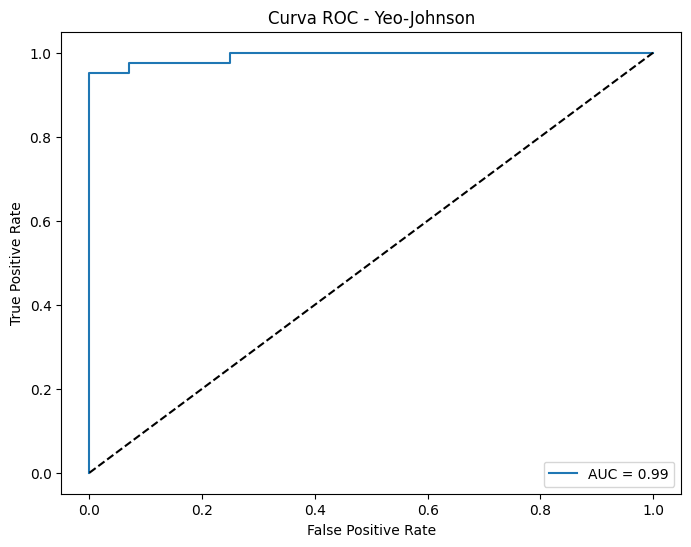

In [ ]:
y_prob = logr_model_yeo.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Yeo-Johnson')
plt.legend()
plt.show()

10. Grafica la distribución de las probabilidades predichas de la clase positiva (Maligno, 1) usando histogramas superpuestos, diferenciando con colores las clases reales Benigno (B) y Maligno (M).
* ¿Cuál es el umbral (*threshold*) por defecto que utiliza scikit-learn para convertir probabilidades en predicciones binarias?
* En un modelo de diagnóstico médico, ¿cuál consideras que es la métrica más importante?
* ¿Cómo cambiarías (disminuir / aumentar) el *threshold*? ¿Por qué?



---
El umbral por defecto en scikit-learn es 0.5.

En diagnóstico médico, Recall es la métrica más importante porque minimizar Falsos Negativos es crítico para evitar retrasos en tratamiento.

Disminuiría el threshold por ejemplo a 0.3 o 0.2 porque en la gráfica se observan casos malignos con probabilidad predicha entre 0.5 y 0.6. Sin embargo, el verdadero riesgo está en los 2 casos malignos que probablemente caen justo por debajo de 0.5.
Este ajuste sí incrementaría los falsos positivos, ya que algunos benignos con probabilidad media cruzarían el nuevo umbral. Sin embargo, en un contexto de diagnóstico médico este costo es aceptable: un falso positivo implica que el doctor realice pruebas adicionales o una falsa alarma, mientras que un falso negativo implica no detectar un cáncer real, con consecuencias mucho más graves. Es preferible que el modelo genere algunas alertas de más, a que se le escape un verdadero caso positivo.

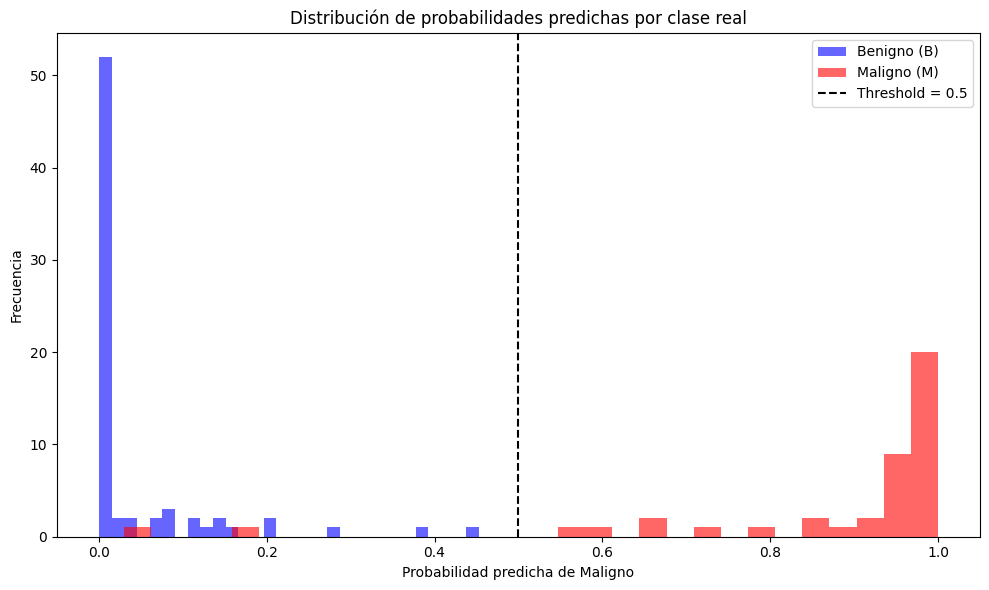

In [ ]:
plt.figure(figsize=(10, 6))

# Separar probabilidades por clase real
proba_benigno = y_prob[y_test == 0]
proba_maligno = y_prob[y_test == 1]

plt.hist(proba_benigno, bins=30, alpha=0.6, label='Benigno (B)', color='blue')
plt.hist(proba_maligno, bins=30, alpha=0.6, label='Maligno (M)', color='red')
plt.axvline(0.5, color='black', linestyle='--', label='Threshold = 0.5')
plt.xlabel('Probabilidad predicha de Maligno')
plt.ylabel('Frecuencia')
plt.title('Distribución de probabilidades predichas por clase real')
plt.legend()
plt.tight_layout()
plt.show()

---

**Declaración de uso de IA**

Si aplica, deberá indicarse la herramienta y el modelo empleado en la entrega, así como la finalidad de su uso (generación de código / depuración / optimización).

Por ejemplo:

*   OpenAI. (2026). *ChatGPT (basado en GPT-4)* [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://chat.openai.com/

---